In [7]:
from langgraph.graph import StateGraph , START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [8]:
load_dotenv()

True

In [9]:
model = ChatGoogleGenerativeAI(
    model = 'gemini-2.5-flash',
    temperature = 0
)

In [10]:
# create a state

class LLMState(TypedDict):

    question: str
    answer : str

In [11]:
def llm_qa(state : LLMState) -> LLMState:
    # extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'answer the following question {question}'

    # ask that question to the LLM
    answer = model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer

    return state



In [5]:
# create graph

graph = StateGraph(LLMState)

In [12]:
# add node

graph.add_node('llm_qa',llm_qa)

In [13]:
# add edges
graph.add_edge(START , 'llm_qa')
graph.add_edge('llm_qa' , END)

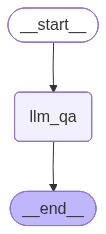

In [14]:
# compile graph

graph.compile()

In [15]:
workflow = graph.compile()

In [16]:
# execute

initial_state = {'question' : 'what do you mean by Photosynthesis'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'question': 'what do you mean by Photosynthesis', 'answer': 'Photosynthesis is the fundamental biochemical process by which **green plants, algae, and some bacteria convert light energy (typically from the sun) into chemical energy.** This chemical energy is stored in organic compounds, primarily **glucose (a sugar)**, which they synthesize from **carbon dioxide and water**.\n\nIn simpler terms, it\'s how plants "make their own food" using sunlight.\n\nHere\'s a breakdown of what that means:\n\n1.  **"Photo" (Light) + "Synthesis" (To Make):** The name itself tells you a lot – it\'s about making something using light.\n\n2.  **Key Ingredients (Reactants):**\n    *   **Sunlight:** Provides the energy to power the process.\n    *   **Carbon Dioxide (CO2):** Absorbed from the atmosphere through tiny pores (stomata) on leaves.\n    *   **Water (H2O):** Absorbed from the soil by the roots.\n\n3.  **The "Kitchen" (Location):**\n    *   Photosynthesis primarily occurs in the **chloroplasts** 